# Model predykcyjny — budowa i ocena

## Cel tego notebooka

W tym notebooku budujemy i oceniamy modele predykcyjne na danych przygotowanych w poprzednim etapie.
Realizujemy dwa podejścia:

1. **Regresja liniowa** (+ warianty Ridge i Lasso) — przewiduje ocenę w skali 1–5
2. **Regresja logistyczna** — przewiduje czy użytkownik polubi film (ocena ≥ 4)

Każdy model jest oceniany na zbiorze testowym (20% danych) który model widzi po raz pierwszy.

In [1]:
import os
os.chdir(os.path.expanduser('~/magisterka'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style="whitegrid")
print("Importy gotowe.")

Importy gotowe.


## Wczytanie danych

Wczytujemy przetworzone dane z etapu preprocessingu.
X_train/X_test to macierze cech po standaryzacji.
y_train/y_test to wektory ocen (wartości 1–5).

In [2]:
X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')

FEATURE_COLS = joblib.load('backend/model/feature_cols.pkl')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Liczba cech: {len(FEATURE_COLS)}")

X_train: (800167, 45)
X_test:  (200042, 45)
Liczba cech: 45


## Baseline — punkt odniesienia

Przed budową właściwego modelu definiujemy **baseline** — najprostszy możliwy
"model" który dla każdego filmu przewiduje dokładnie tę samą wartość: średnią
wszystkich ocen ze zbioru treningowego (~3.58).

Jeśli nasz model nie bije baseline'u, jest bezużyteczny.
Metryki baseline stanowią minimalny poziom do przekroczenia.

In [3]:
baseline_pred = np.full_like(y_test, fill_value=y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE:  {baseline_mae:.4f}")

Baseline RMSE: 1.2621
Baseline MAE:  1.0240


## Regresja liniowa

Główny model pracy. Algorytm OLS (Ordinary Least Squares) szuka współczynników β
które minimalizują sumę kwadratów różnic między ocenami przewidywanymi a rzeczywistymi.

Trenujemy na 80% danych, oceniamy na 20% które model widzi po raz pierwszy.

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_r2   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {lr_rmse:.4f}")
print(f"Linear Regression MAE:  {lr_mae:.4f}")
print(f"Linear Regression R²:   {lr_r2:.4f}")

Linear Regression RMSE: 0.9184
Linear Regression MAE:  0.7288
Linear Regression R²:   0.3273


## Ridge i Lasso — regresja z regularyzacją

**Ridge (L2):** zmniejsza wszystkie współczynniki proporcjonalnie, żaden nie staje
się zerem. Dobry gdy wiele cech ma małe ale realne znaczenie.

**Lasso (L1):** potrafi wyzerować współczynniki nieistotnych cech — robi automatyczną
selekcję zmiennych. Pozwoli nam zobaczyć które cechy model uznaje za zbędne.

Parametr `alpha` kontroluje siłę regularyzacji — im wyższy, tym prostszy model.

In [5]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

results = pd.DataFrame({
    'Model':    ['Baseline', 'Linear Regression', 'Ridge', 'Lasso'],
    'RMSE':     [baseline_rmse,
                 lr_rmse,
                 np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
                 np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
    'MAE':      [baseline_mae,
                 lr_mae,
                 mean_absolute_error(y_test, y_pred_ridge),
                 mean_absolute_error(y_test, y_pred_lasso)],
    'R²':       [0.0,
                 lr_r2,
                 r2_score(y_test, y_pred_ridge),
                 r2_score(y_test, y_pred_lasso)]
}).round(4)

display(results)

,Model,RMSE,MAE,R²
0,Baseline,1.2621,1.0240,0.0000
1,Linear Regression,0.9184,0.7288,0.3273
2,Ridge,0.9184,0.7288,0.3273
3,Lasso,0.9190,0.7300,0.3264


## Wykres porównania modeli regresji

Trzy wykresy słupkowe porównują modele według metryk RMSE, MAE i R².
Niższe RMSE i MAE oznaczają lepszy model. Wyższe R² oznacza lepszy model.
Szary słupek (Baseline) to minimalny poziom do przekroczenia.

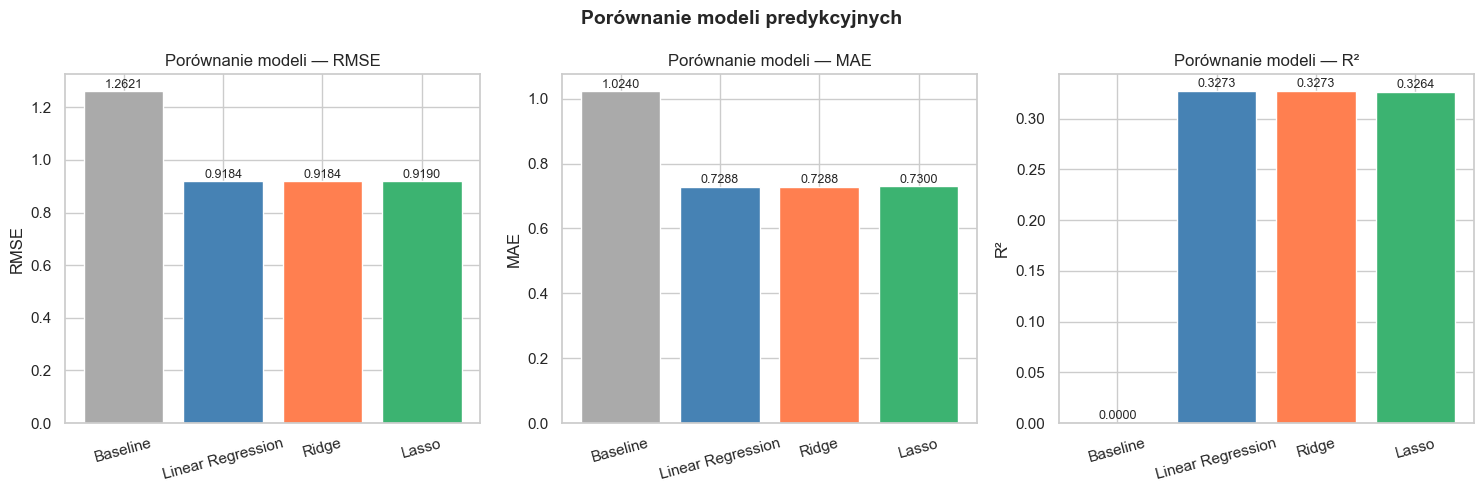

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#aaaaaa', 'steelblue', 'coral', 'mediumseagreen']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='white')
    ax.set_title(f'Porównanie modeli — {metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Porównanie modeli predykcyjnych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot_model_comparison.png', dpi=150)
plt.show()

## Rzeczywiste vs przewidywane oceny

Scatter plot gdzie każdy punkt to jedna ocena z zestawu testowego.
Oś X = ocena rzeczywista, oś Y = ocena przewidywana przez model.
Czerwona linia przerywana = idealne przewidywanie (y = x).

Im bliżej punkty są linii, tym model jest dokładniejszy.
Próbka 2000 losowych punktów dla czytelności wykresu.

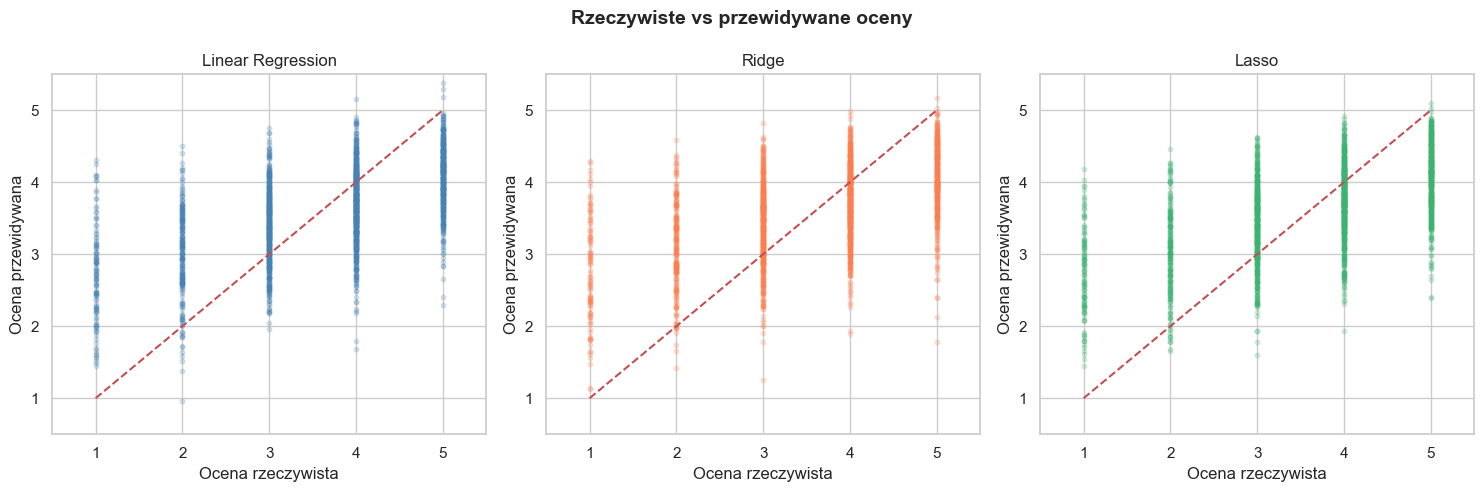

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, preds, name, color in zip(
    axes,
    [y_pred_lr, y_pred_ridge, y_pred_lasso],
    ['Linear Regression', 'Ridge', 'Lasso'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    sample = np.random.choice(len(y_test), 2000, replace=False)
    ax.scatter(y_test[sample], preds[sample], alpha=0.2, s=10, color=color)
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel('Ocena rzeczywista')
    ax.set_ylabel('Ocena przewidywana')
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)

plt.suptitle('Rzeczywiste vs przewidywane oceny', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot_predictions_scatter.png', dpi=150)
plt.show()

## Analiza reszt

**Reszta** = ocena rzeczywista − ocena przewidywana.

Lewy wykres: histogram reszt — powinien być symetryczny względem zera
(model nie powinien systematycznie przeszacowywać ani niedoszacowywać).

Prawy wykres: reszty względem wartości przewidywanych — nie powinno być
żadnego wzorca (losowy "szum" wokół zera). Wzorzec sugerowałby że model
nie uchwycił jakiejś zależności w danych.

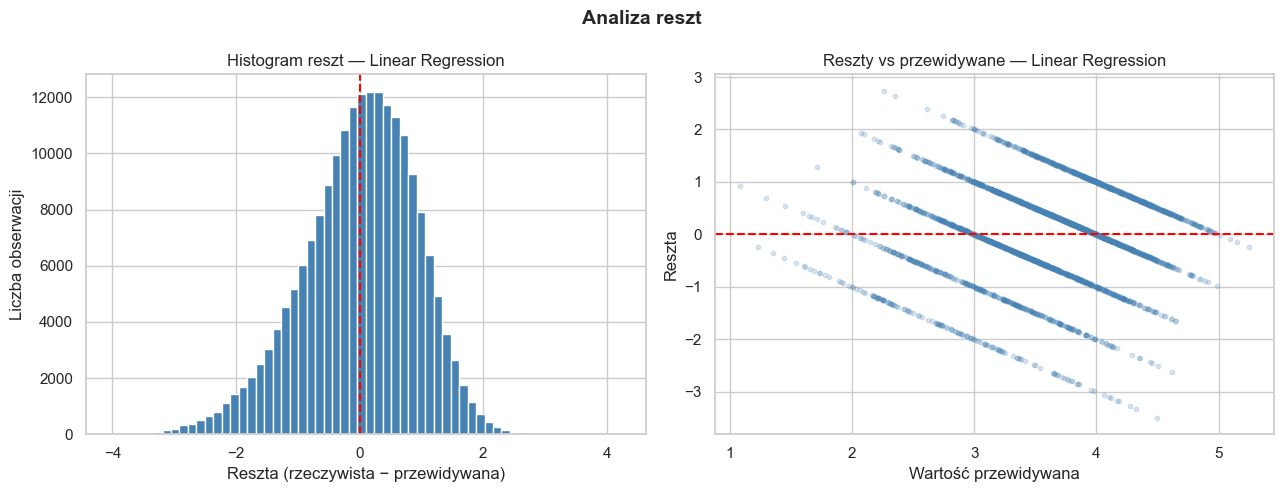

In [8]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Histogram reszt — Linear Regression')
axes[0].set_xlabel('Reszta (rzeczywista − przewidywana)')
axes[0].set_ylabel('Liczba obserwacji')

sample = np.random.choice(len(y_test), 3000, replace=False)
axes[1].scatter(y_pred_lr[sample], residuals[sample], alpha=0.2, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Reszty vs przewidywane — Linear Regression')
axes[1].set_xlabel('Wartość przewidywana')
axes[1].set_ylabel('Reszta')

plt.suptitle('Analiza reszt', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot_residuals.png', dpi=150)
plt.show()

## Współczynniki regresji — które cechy mają największy wpływ?

Wykres pokazuje 20 cech o największym wpływie na przewidywaną ocenę.

**Niebieski słupek (wartość dodatnia):** cecha zwiększa przewidywaną ocenę.
**Koralowy słupek (wartość ujemna):** cecha zmniejsza przewidywaną ocenę.

Wielkość słupka = siła wpływu. Im dłuższy słupek, tym ważniejsza cecha.

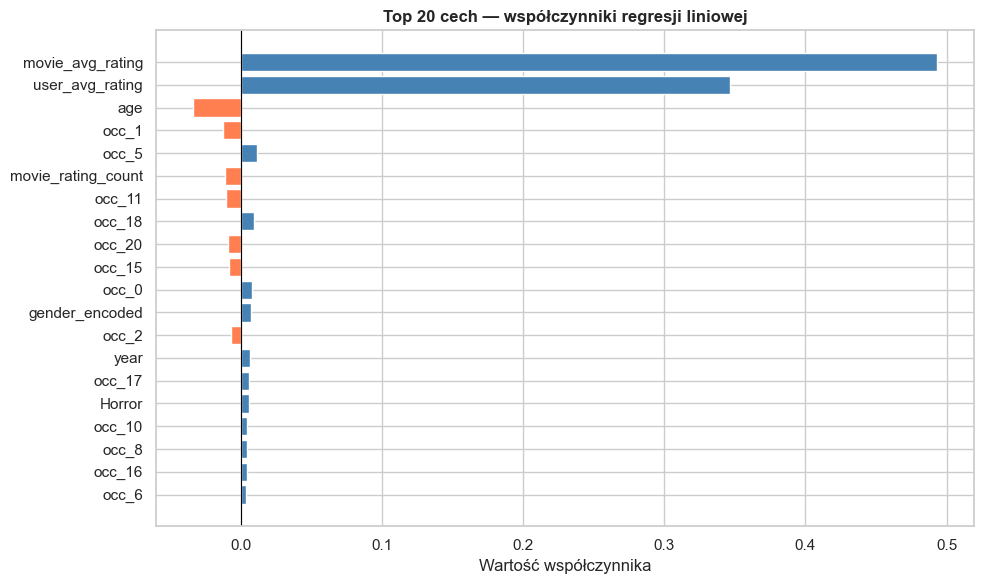

In [9]:
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr.coef_
}).reindex(pd.Series(lr.coef_).abs().sort_values(ascending=False).index)

top20 = coef_df.head(20)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in top20['coefficient']]
plt.barh(top20['feature'][::-1], top20['coefficient'][::-1], color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 cech — współczynniki regresji liniowej', fontweight='bold')
plt.xlabel('Wartość współczynnika')
plt.tight_layout()
plt.savefig('notebooks/plot_coefficients.png', dpi=150)
plt.show()

## Zapis modeli regresji

Zapisujemy wytrenowane modele do plików .pkl.
Aplikacja webowa wczyta je raz przy starcie i używa do przewidywań
bez konieczności ponownego trenowania.

In [10]:
joblib.dump(lr, 'backend/model/linear_model.pkl')
joblib.dump(ridge, 'backend/model/ridge_model.pkl')
joblib.dump(lasso, 'backend/model/lasso_model.pkl')

print("Modele regresji zapisane.")

Modele regresji zapisane.


---
## Regresja logistyczna — model alternatywny

### Przeformułowanie problemu

Do tej pory pytaliśmy: *"Jaką ocenę wystawi użytkownik?"* (regresja)

Teraz pytamy: *"Czy użytkownik polubi ten film?"* (klasyfikacja)

Binaryzacja: ocena ≥ 4 → **1 (polubi)**, ocena < 4 → **0 (nie polubi)**

Próg 4/5 jest uzasadniony — w systemach rekomendacji interesuje nas
rekomendowanie treści które użytkownik oceni wysoko, nie przewidywanie
dokładnej liczby gwiazdek.

In [11]:
y_train_binary = (y_train >= 4).astype(int)
y_test_binary  = (y_test >= 4).astype(int)

polubi    = y_test_binary.sum()
nie_polubi = (1 - y_test_binary).sum()

print(f"Polubi    (1): {polubi:,} ({polubi/len(y_test_binary)*100:.1f}%)")
print(f"Nie polubi (0): {nie_polubi:,} ({nie_polubi/len(y_test_binary)*100:.1f}%)")

Polubi    (1): 115,162 (57.6%)
Nie polubi (0): 84,880 (42.4%)


### Trening regresji logistycznej

`max_iter=1000` — maksymalna liczba iteracji algorytmu optymalizacji.
Domyślna wartość (100) często nie wystarcza dla dużych zbiorów danych
z wieloma cechami — zwiększamy ją żeby algorytm zdążył się zbiec.

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train_binary)
y_pred_log = log_reg.predict(X_test)
y_pred_log_proba = log_reg.predict_proba(X_test)[:, 1]

print("Regresja logistyczna wytrenowana.")
print("\nRaport klasyfikacji:")
print(classification_report(y_test_binary, y_pred_log,
                             target_names=['Nie polubi (0)', 'Polubi (1)']))

Regresja logistyczna wytrenowana.

Raport klasyfikacji:
                precision    recall  f1-score   support

Nie polubi (0)       0.70      0.59      0.64     84880
    Polubi (1)       0.73      0.81      0.77    115162

      accuracy                           0.72    200042
     macro avg       0.72      0.70      0.70    200042
  weighted avg       0.72      0.72      0.71    200042



### Krzywa ROC i AUC

**Krzywa ROC** (Receiver Operating Characteristic) pokazuje jak model
radzi sobie przy różnych progach decyzyjnych (nie tylko przy domyślnym 0.5).

**AUC** (Area Under the Curve) — pole pod krzywą ROC.
- AUC = 1.0 → model idealny
- AUC = 0.5 → model losowy (czerwona linia przerywana)
- AUC = 0.7–0.8 → dobry model
- AUC > 0.8 → bardzo dobry model

/Users/robertpilczuk/magisterka/venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


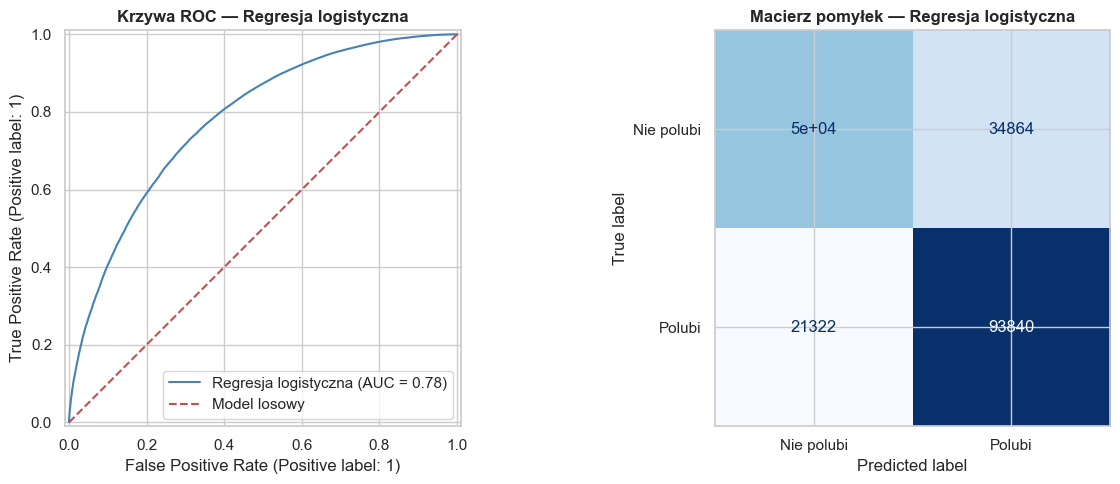

AUC-ROC: 0.7817


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# krzywa ROC
RocCurveDisplay.from_predictions(
    y_test_binary, y_pred_log_proba,
    name='Regresja logistyczna',
    color='steelblue',
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], 'r--', label='Model losowy')
axes[0].set_title('Krzywa ROC — Regresja logistyczna', fontweight='bold')
axes[0].legend()

# macierz pomyłek
ConfusionMatrixDisplay.from_predictions(
    y_test_binary, y_pred_log,
    display_labels=['Nie polubi', 'Polubi'],
    colorbar=False,
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Macierz pomyłek — Regresja logistyczna', fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/plot_logistic_regression.png', dpi=150)
plt.show()

auc = roc_auc_score(y_test_binary, y_pred_log_proba)
print(f"AUC-ROC: {auc:.4f}")

### Macierz pomyłek — interpretacja

Macierz pomyłek pokazuje cztery możliwe wyniki klasyfikacji:

| | Przewidziano: Nie polubi | Przewidziano: Polubi |
|---|---|---|
| **Rzeczywistość: Nie polubi** | ✅ True Negative (TN) | ❌ False Positive (FP) |
| **Rzeczywistość: Polubi** | ❌ False Negative (FN) | ✅ True Positive (TP) |

**False Positive:** model polecił film który użytkownik nie polubił → irytujące
**False Negative:** model nie polecił filmu który by się spodobał → stracona okazja

W systemach rekomendacji zazwyczaj tolerujemy więcej False Positives
niż False Negatives — lepiej zaproponować za dużo niż za mało.

In [14]:
log_accuracy = accuracy_score(y_test_binary, y_pred_log)
log_f1       = f1_score(y_test_binary, y_pred_log)
log_auc      = roc_auc_score(y_test_binary, y_pred_log_proba)

print("=" * 60)
print("MODELE REGRESJI (przewidywanie oceny 1–5)")
print("=" * 60)
display(results)

print("\n" + "=" * 60)
print("MODEL KLASYFIKACJI (czy użytkownik polubi film?)")
print("=" * 60)
results_classification = pd.DataFrame({
    'Model':    ['Regresja logistyczna'],
    'Zadanie':  ['Klasyfikacja (≥4 = polubi)'],
    'Accuracy': [round(log_accuracy, 4)],
    'F1-Score': [round(log_f1, 4)],
    'AUC-ROC':  [round(log_auc, 4)]
})
display(results_classification)

MODELE REGRESJI (przewidywanie oceny 1–5)


,Model,RMSE,MAE,R²
0,Baseline,1.2621,1.0240,0.0000
1,Linear Regression,0.9184,0.7288,0.3273
2,Ridge,0.9184,0.7288,0.3273
3,Lasso,0.9190,0.7300,0.3264



MODEL KLASYFIKACJI (czy użytkownik polubi film?)


,Model,Zadanie,Accuracy,F1-Score,AUC-ROC
0,Regresja logistyczna,Klasyfikacja (≥4 = polubi),0.7191,0.7696,0.7817


In [15]:
joblib.dump(log_reg, 'backend/model/logistic_model.pkl')
print("Model logistyczny zapisany.")

Model logistyczny zapisany.
